In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Handle class imbalance
from imblearn.over_sampling import SMOTE, ADASYN

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Accuracy metrixs
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# For explainable AI
import shap

# To set the grid of charts
sns.set_style("whitegrid")

# Set a random seed so results are reproducible every time we run this notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore")

C:\Users\SATISH\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For consistent Chart Style & color scheme
NORMAL_COLOR = "#4C72B0"
FRAUD_COLOR = "#C44E52"

# same as NORMAL_COLOR, used for single-series charts
ACCENT_COLOR = "#4C72B0"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10

# Add value labels above/beside each bar
def add_bar_labels(ax, fmt="%.1f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=2, fontsize=9)

# Step 1: Data Loading

## 1.1 Load the Dataset
- Loaded the transaction dataset from a CSV file using Pandas.
- The dataset has 14,446 rows and 15 columns, covering transaction details, customer details (age, location) and merchant details (category, location).
- `is_fraud` is the target column, where 1 means fraud and 0 means a normal transaction.

In [3]:
# Load the dataset
df = pd.read_csv("fraud_data.csv")

print("Raw shape:", df.shape)
df.head()

Raw shape: (14446, 15)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


## 1.2 Clean the is_fraud Column
- Found a couple of rows where `is_fraud` had a corrupted value (a timestamp had leaked into the column).
- Removed these rows and converted the column to a clean integer type.
- Row count went from 14,446 to 14,444 after cleaning.

In [4]:
# Check what values currently exist in is_fraud
print("Unique values before cleaning:")
print(df["is_fraud"].unique())

# Keep only rows where is_fraud is exactly "0" or "1"
df = df[df["is_fraud"].isin(["0", "1"])].copy()

# Convert to integer type
df["is_fraud"] = df["is_fraud"].astype(int)

print("\nShape after cleaning:", df.shape)
print("Unique values after cleaning:", df["is_fraud"].unique())

Unique values before cleaning:
<StringArray>
['1', '1"2020-12-24 16:56:24"', '0', '0"2019-01-01 00:00:44"']
Length: 4, dtype: str

Shape after cleaning: (14444, 15)
Unique values after cleaning: [1 0]


## 1.3 Basic Structure of the Data
- Checked data types and column info using `df.info()`.
- Checked all columns for missing values.
- The dataset has no missing values, so no imputation was needed.

In [5]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
Index: 14444 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14444 non-null  str    
 1   merchant               14444 non-null  str    
 2   category               14444 non-null  str    
 3   amt                    14444 non-null  float64
 4   city                   14444 non-null  str    
 5   state                  14444 non-null  str    
 6   lat                    14444 non-null  float64
 7   long                   14444 non-null  float64
 8   city_pop               14444 non-null  int64  
 9   job                    14444 non-null  str    
 10  dob                    14444 non-null  str    
 11  trans_num              14444 non-null  str    
 12  merch_lat              14444 non-null  float64
 13  merch_long             14444 non-null  float64
 14  is_fraud               14444 non-null  int64  
dtypes: float64(5), int

In [6]:
# Check for missing values in each column
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## 1.4 Class Imbalance Check
- Checked how many transactions are fraud vs normal.
- Out of 14,444 transactions, 12,600 are normal (87.2%) and 1,844 are fraud (12.8%).
- This is imbalanced, but not as extreme as typical fraud datasets, so accuracy alone won't be a reliable metric later on.

In [7]:
# Check for the class imbalance
class_counts = df["is_fraud"].value_counts()
print(class_counts)

# Calculate the percentage of the fraud in 0 & 1s
class_percent = df["is_fraud"].value_counts(normalize=True) * 100
print("\nPercentage:")
print(class_percent)

is_fraud
0    12600
1     1844
Name: count, dtype: int64

Percentage:
is_fraud
0    87.233453
1    12.766547
Name: proportion, dtype: float64


# Step 2: Exploratory Data Analysis

## 2.1 Visualize the Class Imbalance
- Plotted the count of normal vs fraud transactions to see the imbalance visually.

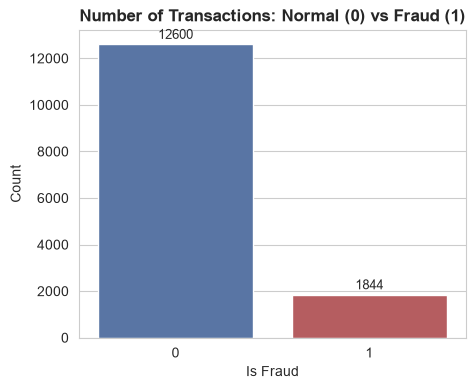

In [8]:
# Visualize the class imbalance
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="is_fraud", data=df, hue="is_fraud",
                    palette=[NORMAL_COLOR, FRAUD_COLOR], legend=False)
add_bar_labels(ax, fmt="%.0f")
plt.title("Number of Transactions: Normal (0) vs Fraud (1)")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

## 2.2 Comparision of Transaction Amount Statistics for Fraud vs Normal
- Compared the summary statistics of transaction amount for both classes.
- Normal transactions have a mean amount of about 66.8, while fraud transactions have a much higher mean of about 518.2.
- This suggests transaction amount is likely to be an important feature for the model.

In [9]:
# Compare transaction amount statistics for fraud vs normal
print("Normal transactions - amt statistics:")
print(df[df["is_fraud"] == 0]["amt"].describe())

print("\nFraud transactions - amt statistics:")
print(df[df["is_fraud"] == 1]["amt"].describe())

Normal transactions - amt statistics:
count    12600.000000
mean        66.814898
std        114.481015
min          1.000000
25%          9.770000
50%         46.140000
75%         81.927500
max       3261.470000
Name: amt, dtype: float64

Fraud transactions - amt statistics:
count    1844.000000
mean      518.233015
std       389.925972
min         1.780000
25%       187.350000
50%       358.655000
75%       884.222500
max      1371.810000
Name: amt, dtype: float64


## 2.3 Amount Distribution for Fraud & Normal
- Plotted the amount distribution separately for both classes to see the shape of the difference, not just the average.

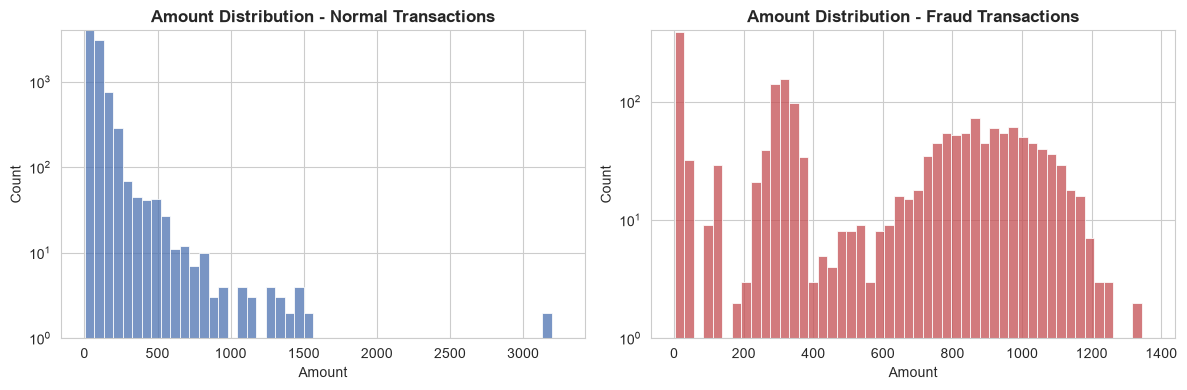

In [10]:
# Plot amount distribution for both classes
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["amt"], bins=50, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Amount Distribution - Normal Transactions")
ax[0].set_xlabel("Amount")
ax[0].set_ylim(1, 4000)
ax[0].set_yscale("log")

sns.histplot(df[df["is_fraud"] == 1]["amt"], bins=50, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Amount Distribution - Fraud Transactions")
ax[1].set_xlabel("Amount")
ax[1].set_ylim(1, 400)
ax[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 2.4 Fraud Rate by Merchant Category
- Calculated the fraud rate for each merchant category.
- `shopping_net`, `grocery_pos`, and `misc_net` have the highest fraud rates, all above 27%.
- `home`, `health_fitness`, and `food_dining` have the lowest fraud rates, all under 5%.
- Category is clearly a useful feature for telling fraud and normal transactions apart.

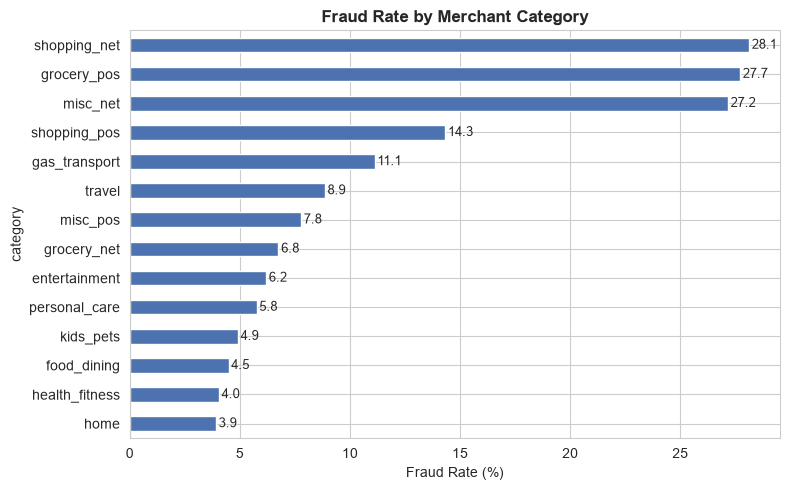

In [11]:
# Fraud rate by merchant category
category_fraud_rate = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
ax = category_fraud_rate.plot(kind="barh", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Fraud Rate (%)")
plt.title("Fraud Rate by Merchant Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2.5 Fraud Rate by State
- Calculated the fraud rate by state to check for any regional pattern.
- Alaska stands out with a much higher fraud rate (37.6%) than any other state, followed by Nebraska and Oregon (16%).
- Alaska also has a small number of transactions in this dataset, so it might be possible due to this fraud rate is high in this state.

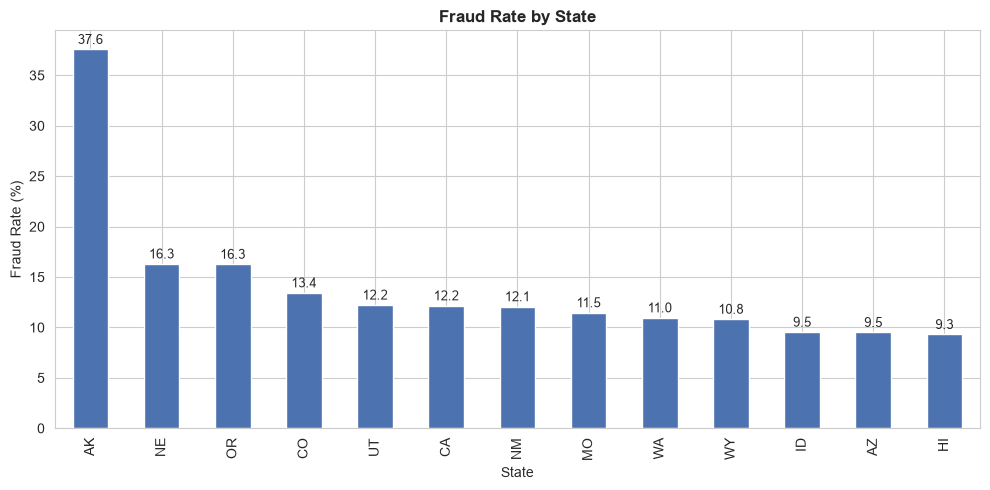

In [12]:
# Fraud rate by state
state_fraud_rate = df.groupby("state")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
ax = state_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("State")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by State")
plt.tight_layout()
plt.show()


## 2.6 Transaction Time Patterns
- Parsed the transaction date/time column so the hour and day of the week could be used as separate features.

In [13]:
# Parse the transaction datetime (format is day-month-year hour:minute)
df["trans_datetime"] = pd.to_datetime(df["trans_date_trans_time"], format="%d-%m-%Y %H:%M")

# Extract hour of day and day of week
df["trans_hour"] = df["trans_datetime"].dt.hour
df["trans_dayofweek"] = df["trans_datetime"].dt.day_name()

df[["trans_date_trans_time", "trans_datetime", "trans_hour", "trans_dayofweek"]].head()

,trans_date_trans_time,trans_datetime,trans_hour,trans_dayofweek
0,04-01-2019 00:58,2019-01-04 00:58:00,0,Friday
1,04-01-2019 15:06,2019-01-04 15:06:00,15,Friday
2,04-01-2019 22:37,2019-01-04 22:37:00,22,Friday
3,04-01-2019 23:06,2019-01-04 23:06:00,23,Friday
4,04-01-2019 23:59,2019-01-04 23:59:00,23,Friday


### 2.6.1 Fraud Rate by Hour of Day
- Grouped transactions by hour and calculated the fraud rate for each.
- Late night hours (11 PM and 10 PM) have the highest fraud rate, both above 40%.
- Daytime hours (like 6 AM-7 AM and 11 AM) have the lowest fraud rate, close to 1.5-2%.
- This is a strong pattern - fraud is far more common at night.

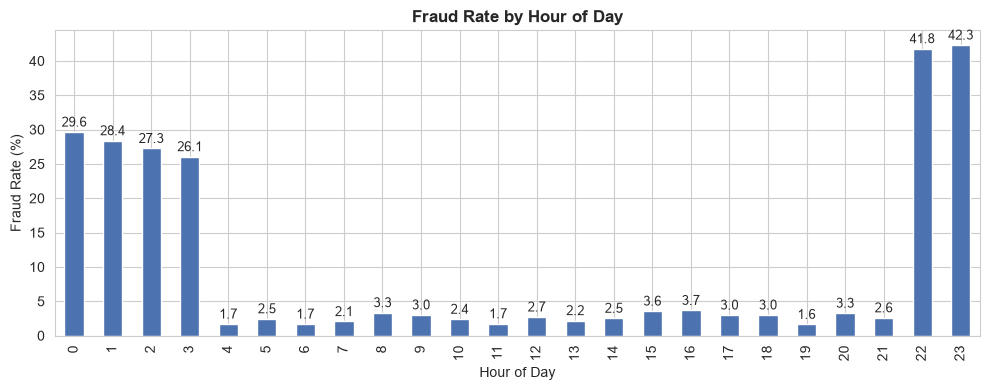

In [14]:
# Fraud rate by hour of day
hour_fraud_rate = df.groupby("trans_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10, 4))
ax = hour_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.tight_layout()
plt.show()

### 2.6.2 Fraud Rate by Day of Week
- Grouped transactions by day of the week to check for a weekly pattern.
- Saturday and Friday show the highest fraud rates (~17.5% and ~16.4%).
- Tuesday shows the lowest fraud rate (~8.6%).
- The difference across days is smaller than the difference across hours.

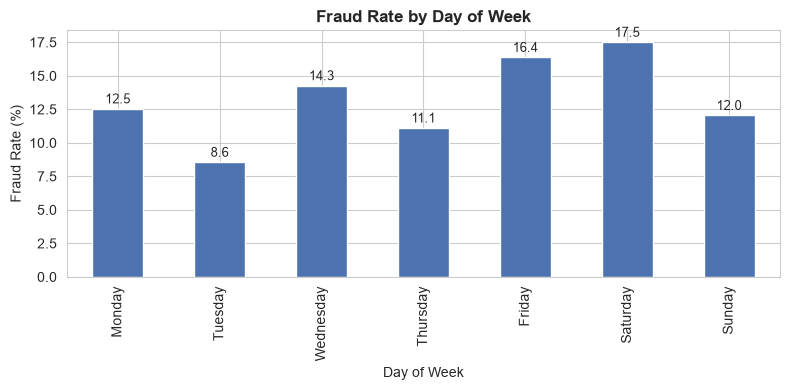

In [15]:
# Fraud rate by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_fraud_rate = df.groupby("trans_dayofweek")["is_fraud"].mean().reindex(day_order) * 100

plt.figure(figsize=(8, 4))
ax = day_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.tight_layout()
plt.show()

## 2.7 Age Distribution by Fraud Vs Normal Transactions
- Calculated customer age at the time of the transaction using date of birth.
- Fraud transactions have a slightly higher average age (50.6 years) compared to normal transactions (47.2 years).
- The difference is small, so age alone isn't a strong signal, but it can still add some value alongside other features.

In [16]:
# Parse date of birth and compute customer age at time of transaction
df["dob_parsed"] = pd.to_datetime(df["dob"], format="%d-%m-%Y")
df["age"] = ((df["trans_datetime"] - df["dob_parsed"]).dt.days / 365.25).astype(int)

df[["dob", "age"]].head()

,dob,age
0,09-11-1939,79
1,09-11-1939,79
2,09-11-1939,79
3,09-11-1939,79
4,09-11-1939,79


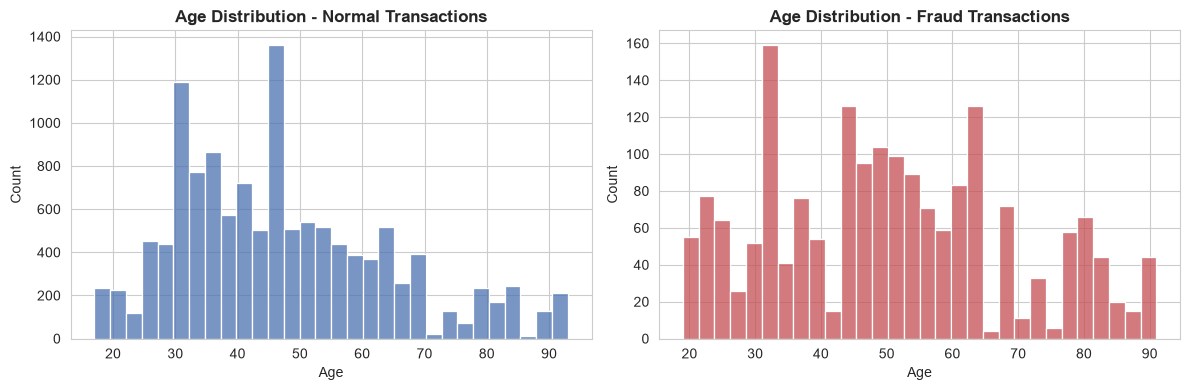

In [17]:
# Age distribution: fraud vs normal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["age"], bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Age Distribution - Normal Transactions")
ax[0].set_xlabel("Age")

sns.histplot(df[df["is_fraud"] == 1]["age"], bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Age Distribution - Fraud Transactions")
ax[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

## 2.8 Customer-Merchant Distance for Fraud Vs Normal Transactions
- Calculated the distance between the customer's location and the merchant's location using the Haversine formula.
- The average distance is almost the same for both classes (~75.9 km for normal, ~75.5 km for fraud).
- So, unlike what is often assumed about fraud happening far from home, this dataset doesn't show a strong distance-based pattern.

In [18]:
# Calculate distance (in km) between customer and merchant using the Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine_distance(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df["distance_km"].describe()

count    14444.000000
mean        75.825980
std         28.717699
min          0.639325
25%         55.438978
50%         77.946241
75%         97.719597
max        143.559991
Name: distance_km, dtype: float64

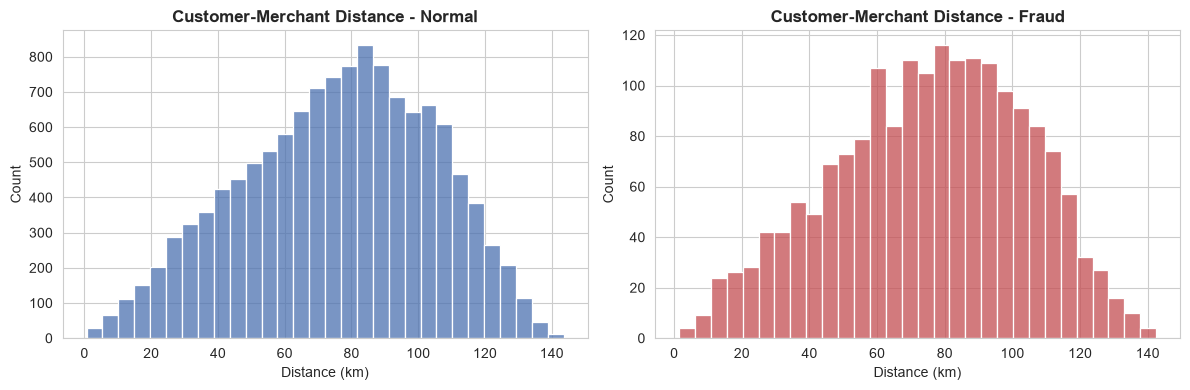

In [19]:
# Distance distribution: fraud vs normal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["distance_km"], bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Customer-Merchant Distance - Normal")
ax[0].set_xlabel("Distance (km)")

sns.histplot(df[df["is_fraud"] == 1]["distance_km"], bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Customer-Merchant Distance - Fraud")
ax[1].set_xlabel("Distance (km)")

plt.tight_layout()
plt.show()

## 2.9 City Population Distribution for Fraud Vs Normal Transactions
- Compared city population between the two classes, using a log scale since population is heavily skewed.
- The distributions look fairly similar overall, with only a slightly higher average population for fraud cases.

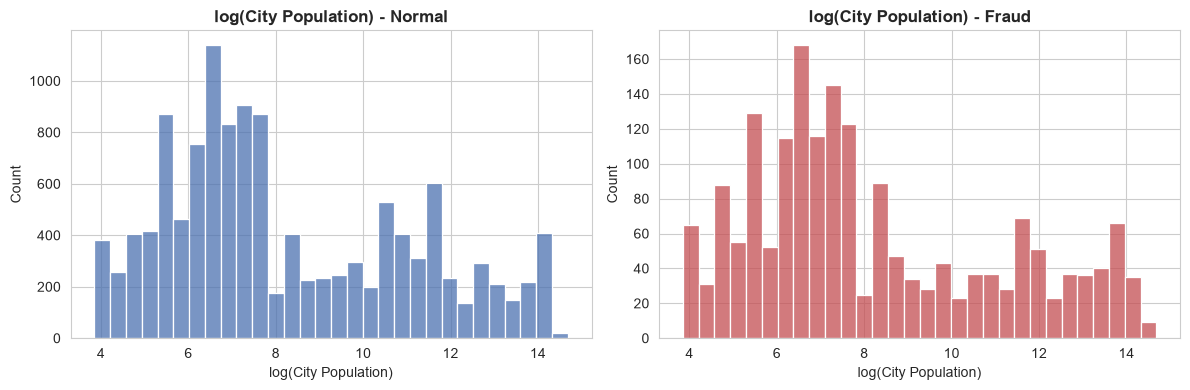

In [20]:
# city_pop is heavily skewed, so log scale is used
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log1p(df[df["is_fraud"] == 0]["city_pop"]), bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("log(City Population) - Normal")
ax[0].set_xlabel("log(City Population)")

sns.histplot(np.log1p(df[df["is_fraud"] == 1]["city_pop"]), bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("log(City Population) - Fraud")
ax[1].set_xlabel("log(City Population)")

plt.tight_layout()
plt.show()

## 2.10 Top 15 Jobs by Fraud Rate
- Looked at fraud rate by job title, keeping only jobs with at least 20 transactions to avoid noisy results from very small groups.
- Some jobs like "Solicitor, Scotland" and "Nature conservation officer" show a high fraud rate (above 40%), but these are based on a small number of transactions, so this pattern is worth treating with some caution.

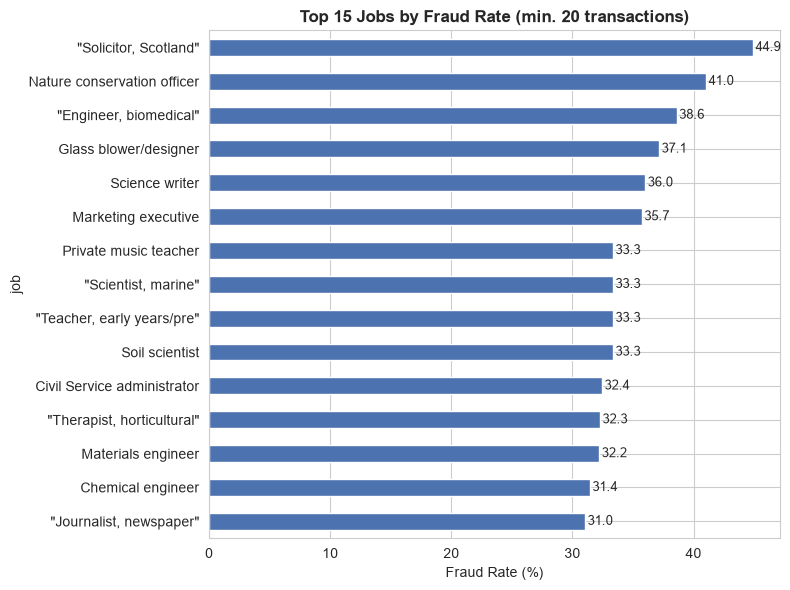

In [21]:
# Only look at jobs with a reasonable number of transactions, to avoid noisy small-sample rates
job_counts = df["job"].value_counts()
common_jobs = job_counts[job_counts >= 20].index

job_fraud_rate = (
    df[df["job"].isin(common_jobs)]
    .groupby("job")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)

plt.figure(figsize=(8, 6))
ax = job_fraud_rate.plot(kind="barh", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Fraud Rate (%)")
plt.title("Top 15 Jobs by Fraud Rate (min. 20 transactions)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

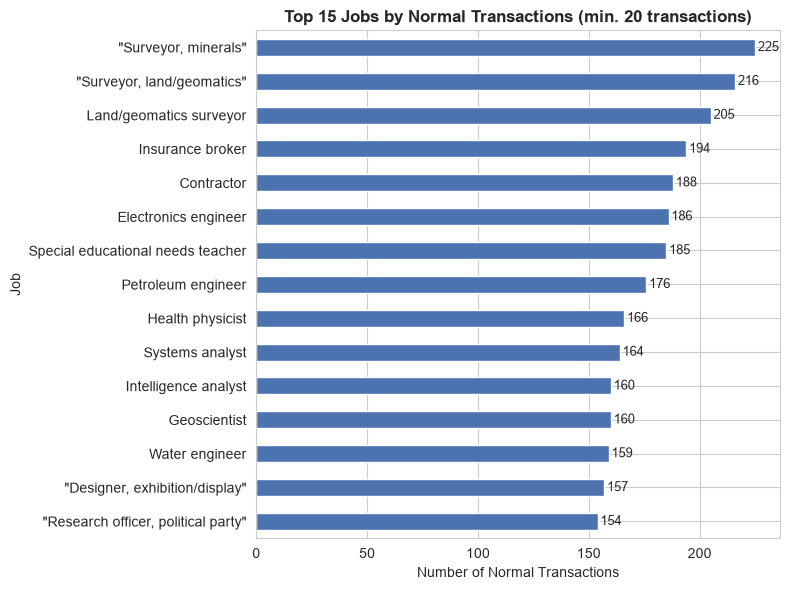

In [22]:
# Only look at jobs with at least 20 normal transactions
normal_df = df[df["is_fraud"] == 0]

job_counts = normal_df["job"].value_counts()
common_jobs = job_counts[job_counts >= 20].index

# Top 15 jobs by number of normal transactions
top_normal_jobs = (
    normal_df[normal_df["job"].isin(common_jobs)]
    ["job"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(8, 6))
ax = top_normal_jobs.sort_values().plot(
    kind="barh",
    color=ACCENT_COLOR
)

add_bar_labels(ax, fmt="%.0f")
plt.xlabel("Number of Normal Transactions")
plt.ylabel("Job")
plt.title("Top 15 Jobs by Normal Transactions (min. 20 transactions)")
plt.tight_layout()
plt.show()

## 2.11 Transaction Amount by Class
- Plotted a boxplot of transaction amount by class (log scale) to get a cleaner view than the histograms alone.
- Fraud transactions clearly sit at a higher amount range than normal ones, matching what was seen earlier in the section 2.2.

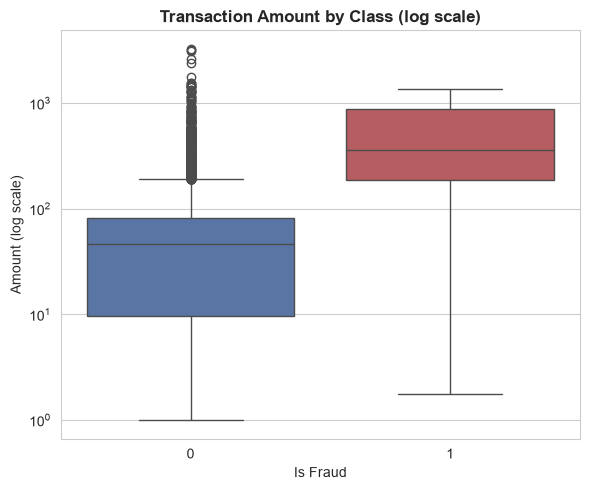

In [23]:
# Boxplot gives a cleaner view of the amount difference than histograms alone
plt.figure(figsize=(6, 5))
sns.boxplot(x="is_fraud", y="amt", data=df, hue="is_fraud",
            palette=[NORMAL_COLOR, FRAUD_COLOR], legend=False)
plt.yscale("log")
plt.xlabel("Is Fraud")
plt.ylabel("Amount (log scale)")
plt.title("Transaction Amount by Class (log scale)")
plt.tight_layout()
plt.show()

## 2.12 Correlation Heatmap for Numeric Features
- Checked correlation between the numeric/engineered features and the target.
- `amt` has by far the strongest correlation with `is_fraud` (~0.65).
- Other features like age, transaction hour, city population, and distance show only weak correlation on their own, but they can still help the model when combined with other features.

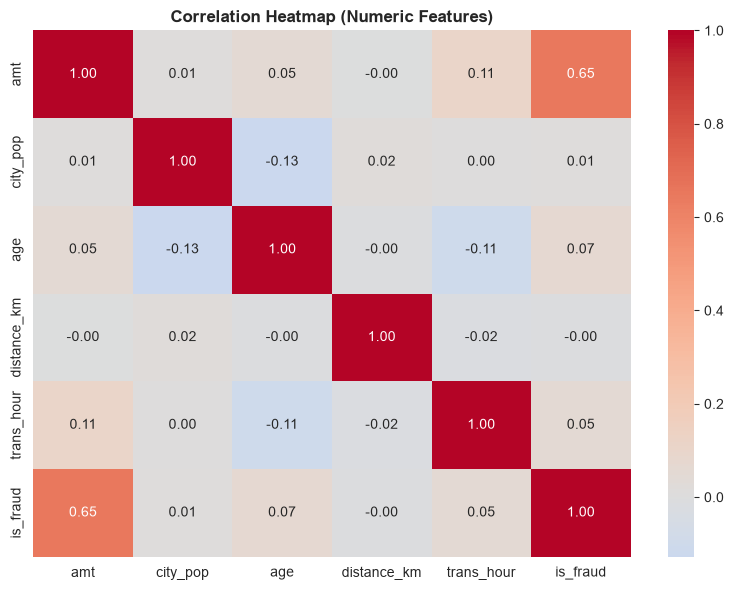

In [24]:
# Correlation heatmap of the numeric columns including the engineered ones
numeric_cols = ["amt", "city_pop", "age", "distance_km", "trans_hour", "is_fraud"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

# Step 3: Preprocessing

## 3.1 Choose the Final Feature set
- Dropped columns that don't add direct value to the model: identifiers (`trans_num`), raw date/location fields already used to build better features (`trans_date_trans_time`, `dob`, `lat`, `long`, `merch_lat`, `merch_long`), and high-cardinality text fields (`merchant`, `city`, `job`).
- Kept the features that showed a real pattern during EDA: `amt`, `category`, `state`, `city_pop`, `age`, `distance_km`, `trans_hour`, `trans_dayofweek`.

In [25]:
# Drop below columns
drop_cols = [
    "trans_num", "trans_date_trans_time", "trans_datetime",
    "dob", "dob_parsed", "merchant", "city", "job",
    "lat", "long", "merch_lat", "merch_long",
]

features_df = df.drop(columns=drop_cols)
features_df.columns.tolist()

['category',
 'amt',
 'state',
 'city_pop',
 'is_fraud',
 'trans_hour',
 'trans_dayofweek',
 'age',
 'distance_km']

## 3.2 Encode Categorical Features
- Used one-hot encoding on `category`, `state`, and `trans_dayofweek` so the model can work with them as numbers.
- One-hot encoding was chosen because these are simple category labels with no natural order, so keeping the feature names readable also helps later when reading the SHAP explanations.

In [26]:
# One-hot encode the categorical columns
categorical_cols = ["category", "state", "trans_dayofweek"]

features_df = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", features_df.shape)
features_df.head()

Shape after encoding: (14444, 37)


,amt,city_pop,is_fraud,trans_hour,age,distance_km,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,...,state_OR,state_UT,state_WA,state_WY,trans_dayofweek_Monday,trans_dayofweek_Saturday,trans_dayofweek_Sunday,trans_dayofweek_Thursday,trans_dayofweek_Tuesday,trans_dayofweek_Wednesday
0,14.37,145,1,0,79,109.285552,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,966.11,145,1,15,79,79.856896,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,49.61,145,1,22,79,66.807915,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,295.26,145,1,23,79,39.636227,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,18.17,145,1,23,79,77.611529,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3.3 Separate Features & Target
- Split the data into `X` (features) and `y` (the `is_fraud` target).

In [27]:
# Split into features (X) and target (y)
X = features_df.drop(columns=["is_fraud"])
y = features_df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14444, 36)
y shape: (14444,)


## 3.4 Train-Test Split
- Split the data into 80% training and 20% testing.
- Used stratified splitting so the fraud percentage stays roughly the same in both sets (~12.8% in train, ~12.8% in test).

In [28]:
# 80-20 train-test split, stratified so fraud ratio stays the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nFraud % in train:", y_train.mean() * 100)
print("Fraud % in test:", y_test.mean() * 100)

Train shape: (11555, 36)
Test shape: (2889, 36)

Fraud % in train: 12.765036780614453
Fraud % in test: 12.77258566978193


## 3.5 Scale Numerical Features
- Scaled `amt`, `city_pop`, `age`, `distance_km`, and `trans_hour` using RobustScaler.
- RobustScaler was chosen over StandardScaler because `amt` and `city_pop` have extreme outliers, which would distort a mean/standard-deviation based scale.
- The scaler was fit only on the training data and then applied to the test data, to avoid any leakage from test to train.

In [29]:
numeric_cols = ["amt", "city_pop", "age", "distance_km", "trans_hour"]

scaler = RobustScaler()

# Fit on training data only
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test data using the same scaler
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe()

,amt,city_pop,age,distance_km,trans_hour
count,11555.000000,11555.000000,11555.000000,11555.000000,11555.000000
mean,0.830159,3.020319,0.103287,-0.046945,-0.077103
std,2.636673,8.276934,0.688528,0.679298,0.561521
min,-0.572895,-0.045431,-1.120000,-1.830546,-1.076923
25%,-0.445293,-0.032276,-0.440000,-0.528353,-0.538462
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.554707,0.967724,0.560000,0.471647,0.461538
max,36.606762,67.685731,1.920000,1.557506,0.692308


# Step 4: Handling Class Imbalance
Since fraud is a minority class, this step checks a few different ways of handling that imbalance, using Logistic Regression as a simple, fast baseline model to compare them fairly.

In [30]:
# Dictionary to store results
imbalance_results = {}

## 4.1 Baseline: Raw Data(No Imbalance Handling)
- Trained Logistic Regression directly on the imbalanced training data, with no special handling.
- Got an F1-Score of 0.7472 for the fraud class.

In [31]:
# Train baseline Logistic Regression on the raw, imbalanced data
model_raw = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)
f1_raw = f1_score(y_test, y_pred_raw)

imbalance_results["Raw (no handling)"] = f1_raw
print("F1-Score (raw):", round(f1_raw, 4))

F1-Score (raw): 0.7472


## 4.2 Class Weighting
- Trained the same model, but with `class_weight="balanced"` so the model pays more attention to the minority (fraud) class.
- F1-Score dropped slightly to 0.5851, lower than the raw baseline.

In [32]:
# class_weight="balanced" automatically gives more importance to the minority (fraud) class
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
f1_weighted = f1_score(y_test, y_pred_weighted)

imbalance_results["Class Weighting"] = f1_weighted
print("F1-Score (class weighting):", round(f1_weighted, 4))

F1-Score (class weighting): 0.586


## 4.3 SMOTE(Synthetic Minority Over-sampling)
- Used SMOTE to create synthetic fraud examples so the training data becomes balanced (10,080 vs 10,080).
- F1-Score came out to 0.6473, still lower than the raw baseline.

In [33]:
# Oversample the fraud cases using SMOTE (training data only)
smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

model_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote)

imbalance_results["SMOTE"] = f1_smote
print("\nF1-Score (SMOTE):", round(f1_smote, 4))


Before SMOTE: {0: 10080, 1: 1475}
After SMOTE: {0: 10080, 1: 10080}

F1-Score (SMOTE): 0.6465


## 4.4 ADASYN(Adaptive Synthetic Sampling)
- Used ADASYN, a variation of SMOTE that focuses more on harder-to-learn fraud cases.
- F1-Score was 0.5193, the lowest of all four methods.

In [34]:
# Oversample the fraud cases using ADASYN (training data only)
adasyn = ADASYN(random_state=RANDOM_SEED)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Before ADASYN:", y_train.value_counts().to_dict())
print("After ADASYN:", y_train_adasyn.value_counts().to_dict())

model_adasyn = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test)
f1_adasyn = f1_score(y_test, y_pred_adasyn)

imbalance_results["ADASYN"] = f1_adasyn
print("\nF1-Score (ADASYN):", round(f1_adasyn, 4))


Before ADASYN: {0: 10080, 1: 1475}
After ADASYN: {0: 10080, 1: 9956}

F1-Score (ADASYN): 0.5193


## 4.5 Compare All Methods for Logistic Regression
- Compared all four methods side by side using F1-Score.
- The raw data (no resampling) actually performed best. This makes sense here because the fraud rate (~12.8%) isn't as extreme as typical fraud datasets, so the model already sees enough real fraud examples, and the synthetic samples from SMOTE/ADASYN seem to add noise rather than help.
- Going forward, the raw training data (no resampling) is used for model training in the next step.

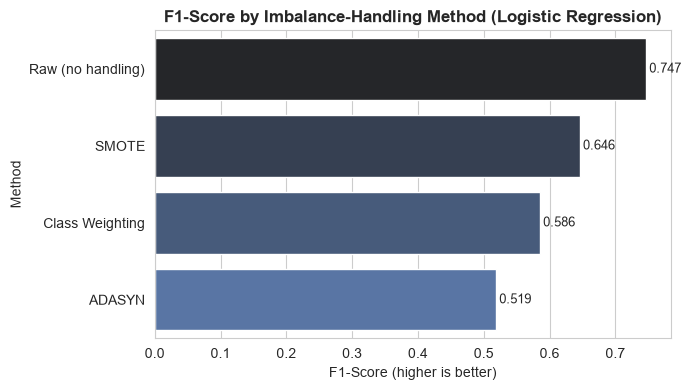

In [35]:
# Compare F1-Score across all imbalance-handling methods
results_df = pd.DataFrame(
    list(imbalance_results.items()), columns=["Method", "F1-Score"]
).sort_values("F1-Score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=results_df, x="F1-Score", y="Method", hue="Method",
                  color=ACCENT_COLOR, legend=False)
add_bar_labels(ax, fmt="%.3f")
plt.title("F1-Score by Imbalance-Handling Method (Logistic Regression)")
plt.xlabel("F1-Score (higher is better)")
plt.tight_layout()
plt.show()


In [36]:
best_method = results_df.iloc[0]["Method"]
print("Best method by F1-Score:", best_method)

# Map method name back to its predictions for a detailed report
pred_lookup = {
    "Raw (no handling)": y_pred_raw,
    "Class Weighting": y_pred_weighted,
    "SMOTE": y_pred_smote,
    "ADASYN": y_pred_adasyn,
}

best_preds = pred_lookup[best_method]

print(f"\nClassification report for '{best_method}':\n")
print(classification_report(y_test, best_preds, target_names=["Normal", "Fraud"]))

Best method by F1-Score: Raw (no handling)

Classification report for 'Raw (no handling)':

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      2520
       Fraud       0.92      0.63      0.75       369

    accuracy                           0.95      2889
   macro avg       0.93      0.81      0.86      2889
weighted avg       0.94      0.95      0.94      2889



# Step 5: Train & Compare Multiple Machine Learning Models on Raw Data
Trained four different models on the raw training data and checked each one's accuracy, classification report, and confusion matrix.

In [37]:
# List to store each model's metrics
model_metrics = []

## 5.1 Model 1: Logistic Regression
- Trained Logistic Regression and evaluated it on the test set.
- Accuracy came out to 94.57%, with an F1-Score of 0.75 for the fraud class - decent, but the weakest of the four models tried.

In [38]:
# Define Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
# Train model
lr.fit(X_train, y_train)

# Predict the result for test set
y_pred_lr = lr.predict(X_test)

# Calculate the testing accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", round(acc_lr, 4))
print()
print(classification_report(y_test, y_pred_lr, target_names=["Normal", "Fraud"]))

Accuracy: 0.9457

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      2520
       Fraud       0.92      0.63      0.75       369

    accuracy                           0.95      2889
   macro avg       0.93      0.81      0.86      2889
weighted avg       0.94      0.95      0.94      2889



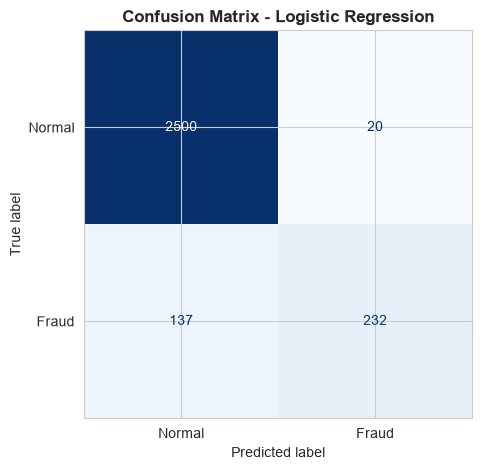

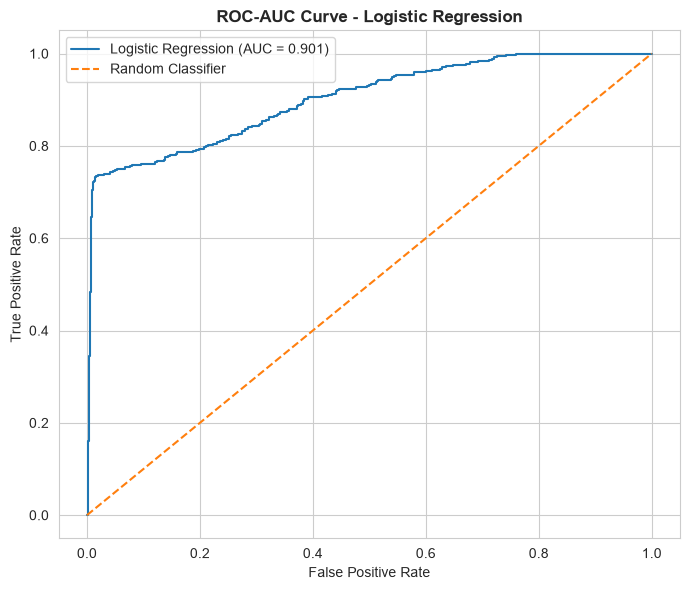

In [39]:
# Display confusion metrix for Logistic Regression model
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# ROC-AUC Curve
y_prob_lr = lr.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# Save this model's key metrics for the fraud class
report_lr = classification_report(y_test, y_pred_lr, target_names=["Normal", "Fraud"], output_dict=True)
model_metrics.append({
    "Model": "Logistic Regression",
    "Accuracy": acc_lr,
    "Precision (Fraud)": report_lr["Fraud"]["precision"],
    "Recall (Fraud)": report_lr["Fraud"]["recall"],
    "F1-Score (Fraud)": report_lr["Fraud"]["f1-score"],
})

## 5.2 Model 2: Decision Tree
- Trained a Decision Tree classifier.
- Accuracy improved to 97.4%, with the fraud F1-Score jumping up to 0.90 - a big improvement over Logistic Regression.

In [40]:
# Define Decision TreeModel
dt = DecisionTreeClassifier(random_state=RANDOM_SEED)
# Train model
dt.fit(X_train, y_train)

# Predict the result for test set
y_pred_dt = dt.predict(X_test)

# Calculate the testing accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", round(acc_dt, 4))
print()
print(classification_report(y_test, y_pred_dt, target_names=["Normal", "Fraud"]))

Accuracy: 0.974

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      2520
       Fraud       0.89      0.91      0.90       369

    accuracy                           0.97      2889
   macro avg       0.94      0.95      0.94      2889
weighted avg       0.97      0.97      0.97      2889



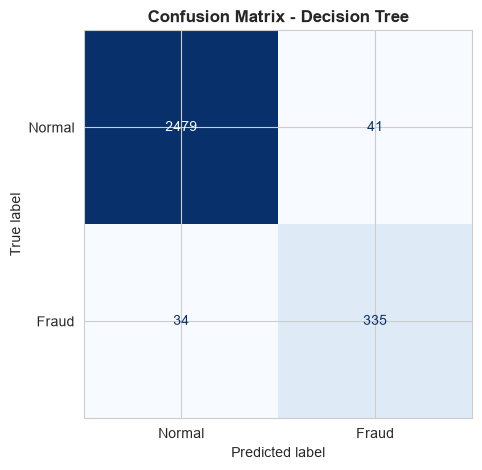

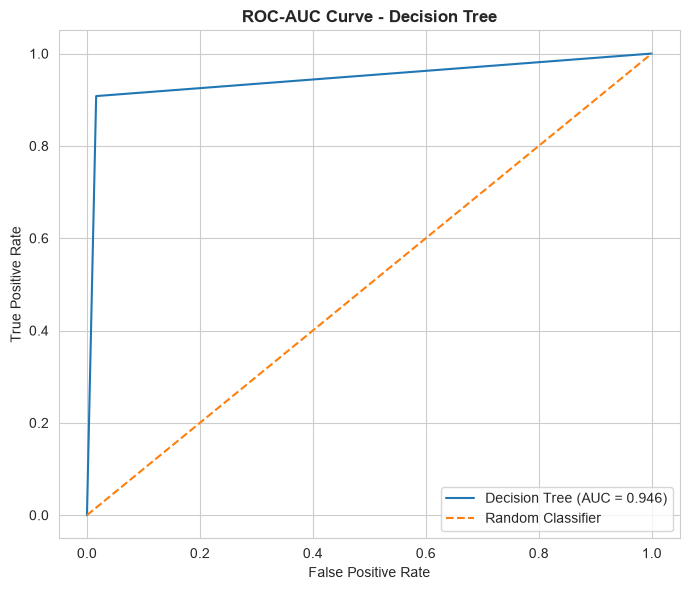

In [41]:
# Display confusion metrix for Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

# ROC-AUC Curve
y_prob_dt = dt.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Save this model's key metrics for the fraud class
report_dt = classification_report(y_test, y_pred_dt, target_names=["Normal", "Fraud"], output_dict=True)
model_metrics.append({
    "Model": "Decision tree",
    "Accuracy": acc_dt,
    "Precision (Fraud)": report_dt["Fraud"]["precision"],
    "Recall (Fraud)": report_dt["Fraud"]["recall"],
    "F1-Score (Fraud)": report_dt["Fraud"]["f1-score"],
})

## 5.3 Model 3: Random Forest
- Trained a Random Forest classifier.
- Accuracy came out to 98.1%, with an F1-Score of 0.92 for the fraud class, slightly better than the Decision Tree.

In [42]:
# Define Random Forest Model
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
# Train model
rf.fit(X_train, y_train)

# Predict the result for test set
y_pred_rf = rf.predict(X_test)

# Calculate the testing accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", round(acc_rf, 4))
print()
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Fraud"]))

Accuracy: 0.981

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      2520
       Fraud       0.97      0.88      0.92       369

    accuracy                           0.98      2889
   macro avg       0.98      0.94      0.96      2889
weighted avg       0.98      0.98      0.98      2889



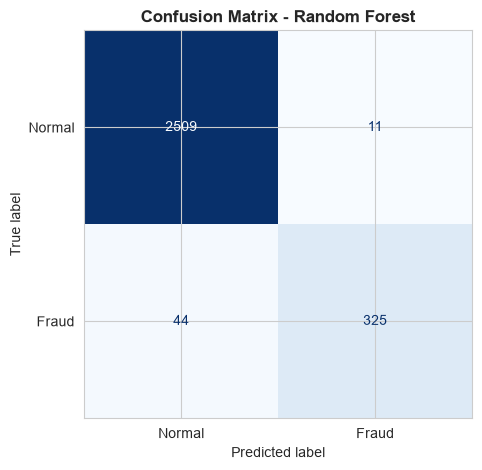

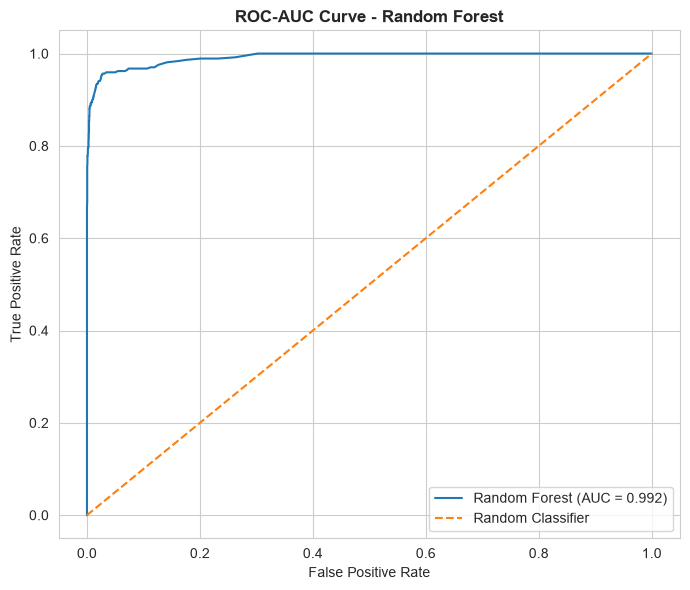

In [43]:
# Display confusion metrix for Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# ROC-AUC Curve
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# Save this model's key metrics for the fraud class
report_rf = classification_report(y_test, y_pred_rf, target_names=["Normal", "Fraud"], output_dict=True)
model_metrics.append({
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Precision (Fraud)": report_rf["Fraud"]["precision"],
    "Recall (Fraud)": report_rf["Fraud"]["recall"],
    "F1-Score (Fraud)": report_rf["Fraud"]["f1-score"],
})

## 5.4 Model 4: XGBoost
- Trained an XGBoost classifier.
- Accuracy came out to 98.23%, with an F1-Score of 0.93 for the fraud class - the best result among all four models.

In [44]:
# Define XGBoost Model
xgb = XGBClassifier(
    n_estimators=200, random_state=RANDOM_SEED,
    eval_metric="logloss", use_label_encoder=False
)
# Train model
xgb.fit(X_train, y_train)

# Predict the result for test set
y_pred_xgb = xgb.predict(X_test)

# Calculate the testing accuracy
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy:", round(acc_xgb, 4))
print()
print(classification_report(y_test, y_pred_xgb, target_names=["Normal", "Fraud"]))

Accuracy: 0.9823

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2520
       Fraud       0.95      0.91      0.93       369

    accuracy                           0.98      2889
   macro avg       0.97      0.95      0.96      2889
weighted avg       0.98      0.98      0.98      2889



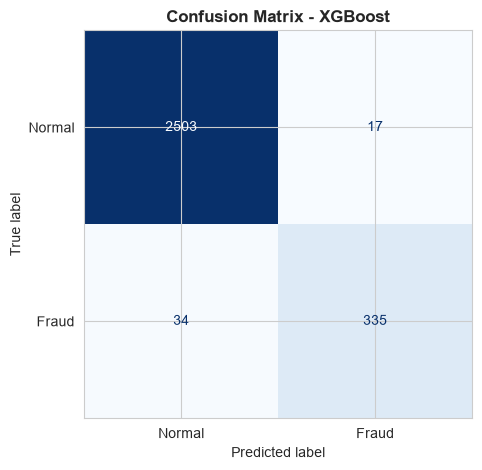

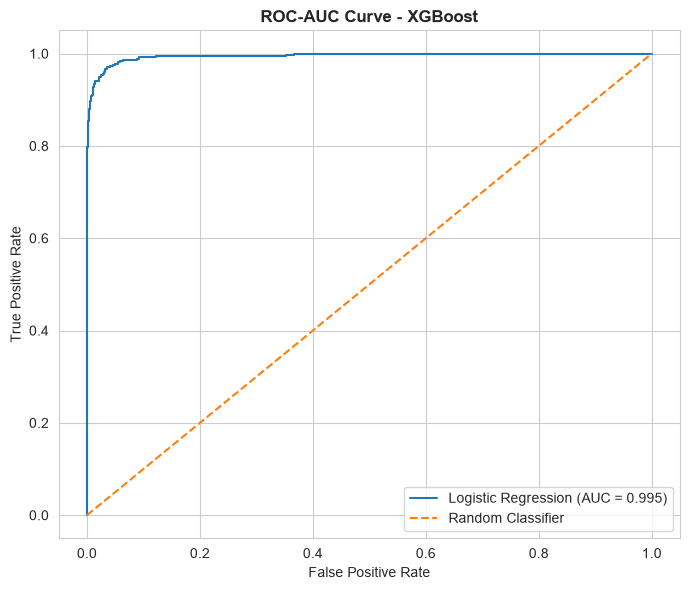

In [45]:
# Display confusion metrix for XGBoost model
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

# ROC-AUC Curve
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"Logistic Regression (AUC = {roc_auc_xgb:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

# Save this model's key metrics for the fraud class
report_xgb = classification_report(y_test, y_pred_xgb, target_names=["Normal", "Fraud"], output_dict=True)
model_metrics.append({
    "Model": "XGBoost",
    "Accuracy": acc_xgb,
    "Precision (Fraud)": report_xgb["Fraud"]["precision"],
    "Recall (Fraud)": report_xgb["Fraud"]["recall"],
    "F1-Score (Fraud)": report_xgb["Fraud"]["f1-score"],
})

## 5.5 Compare all ML Models
- Put all four models' Accuracy, Precision, Recall, and F1-Score (fraud class) together in one table and chart.
- XGBoost comes out on top by F1-Score, followed closely by Random Forest. Logistic Regression is clearly the weakest of the four.

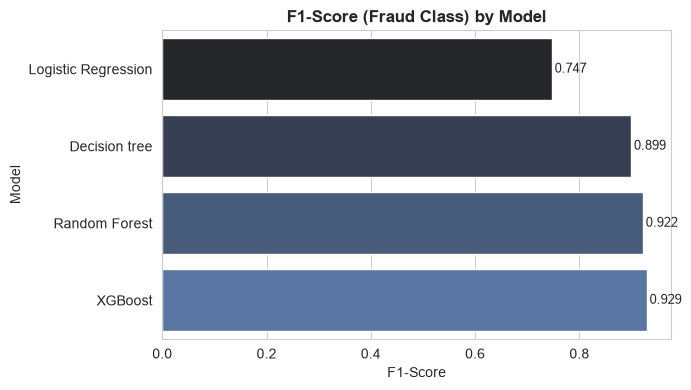

In [46]:
# Compare F1-Score (fraud class) across all four models
metrics_df = pd.DataFrame(model_metrics).round(4)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=metrics_df, x="F1-Score (Fraud)", y="Model",
                  hue="Model", color=ACCENT_COLOR, legend=False)
add_bar_labels(ax, fmt="%.3f")
plt.title("F1-Score (Fraud Class) by Model")
plt.xlabel("F1-Score")
plt.tight_layout()
plt.show()


# Step 6: SHAP Integration for Core Interpretability
Now that a model has been selected, SHAP (SHapley Additive exPlanations) is used to understand *why* the model makes the predictions it does, both overall and for individual transactions.

## 6.1 Model Selection
- Selected XGBoost as the final model, since it had the best F1-Score, along with the best accuracy and precision, in Step 5.

In [47]:
# XGBoost gave the best F1-Score, so it's selected as the final model
final_model = xgb
print("Primary model selected: XGBoost")
print(final_model)

Primary model selected: XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


## 6.2 Build the Explainer
- Built a SHAP `TreeExplainer` for the selected model.
- TreeExplainer was used because it is fast and gives exact results for tree-based models like XGBoost, unlike some other SHAP explainers that only approximate.

In [48]:
# TreeExplainer is fast and exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

## 6.3 Global Explanation: Which features matter most overall?
- Plotted a SHAP summary (beeswarm) plot and a bar plot to see which features drive the model's predictions the most across all transactions.

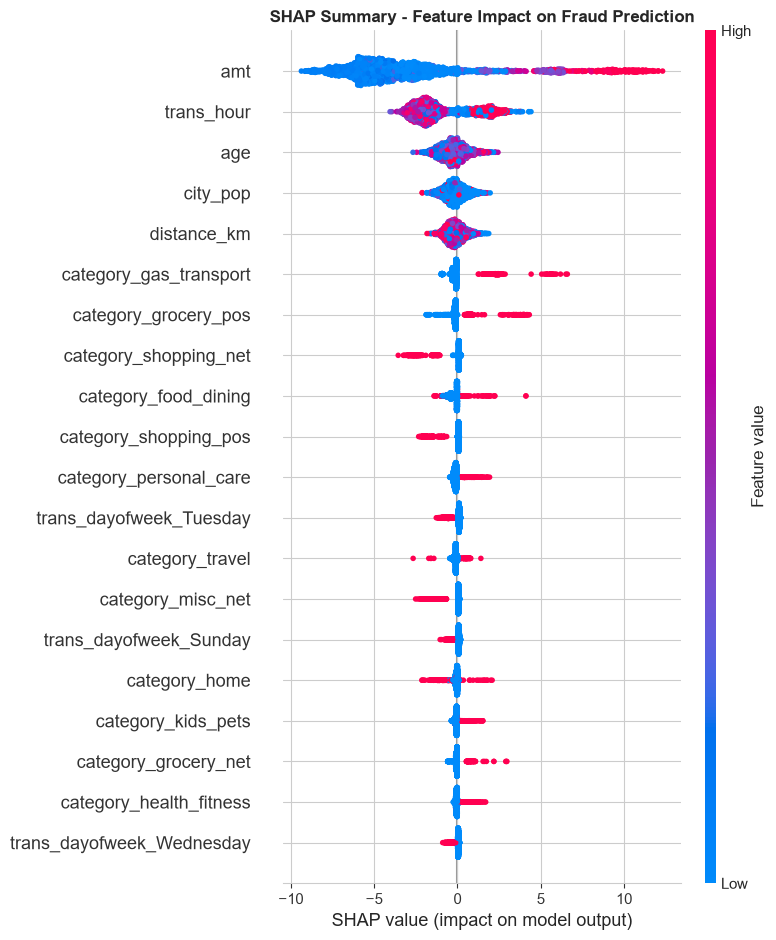

In [49]:
# Beeswarm plot - shows how each feature pushes predictions across all transactions
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary - Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.show()


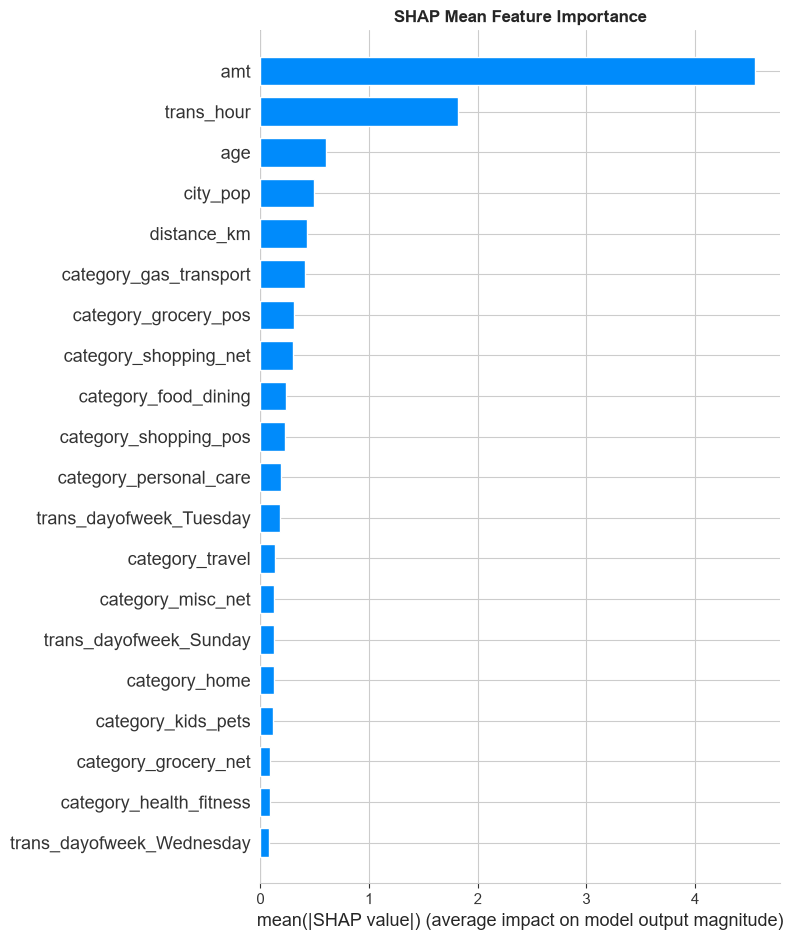

In [50]:
# Bar plot - shows average feature importance across all transactions
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Mean Feature Importance")
plt.tight_layout()
plt.show()


**What these plots show:**
- `amt` (transaction amount) stands out as the single biggest driver of the model's fraud predictions, by a clear margin - matching what was already seen in the EDA and correlation heatmap.
- `trans_hour` is the second most influential feature, which lines up with the earlier finding that fraud is far more common late at night.
- After that, `age`, `city_pop`, and `distance_km` contribute a smaller but still noticeable amount.
- A few merchant categories (like `gas_transport`, `grocery_pos`, `shopping_net`) also show up as useful signals, consistent with the fraud-rate-by-category chart from the EDA.
- In the beeswarm plot, the red (high value) points for `amt` mostly sit on the right side, meaning higher transaction amounts push the prediction towards fraud, which is the expected direction.

## 6.4 Local Explanations: Individual Transactions
- Picked one true positive, one false positive, and one false negative from the test set predictions, to look at how the model reasoned about each one individually.

In [51]:
# Get predictions for the whole test set
y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= 0.5).astype(int)

y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

# Find one example of each case
tp_idx = np.where((y_pred_final == 1) & (y_test_reset == 1))[0][0]
fp_idx = np.where((y_pred_final == 1) & (y_test_reset == 0))[0][0]
fn_idx = np.where((y_pred_final == 0) & (y_test_reset == 1))[0][0]

print("True Positive index:", tp_idx)
print("False Positive index:", fp_idx)
print("False Negative index:", fn_idx)

True Positive index: 2
False Positive index: 155
False Negative index: 33


### 6.4.1 True Positive: Correctly Caught Fraud
- This transaction was predicted as fraud with very high confidence, and it was actually fraud.
- The waterfall plot shows `amt` was by far the biggest factor pushing the prediction towards fraud, along with an unusual transaction hour.

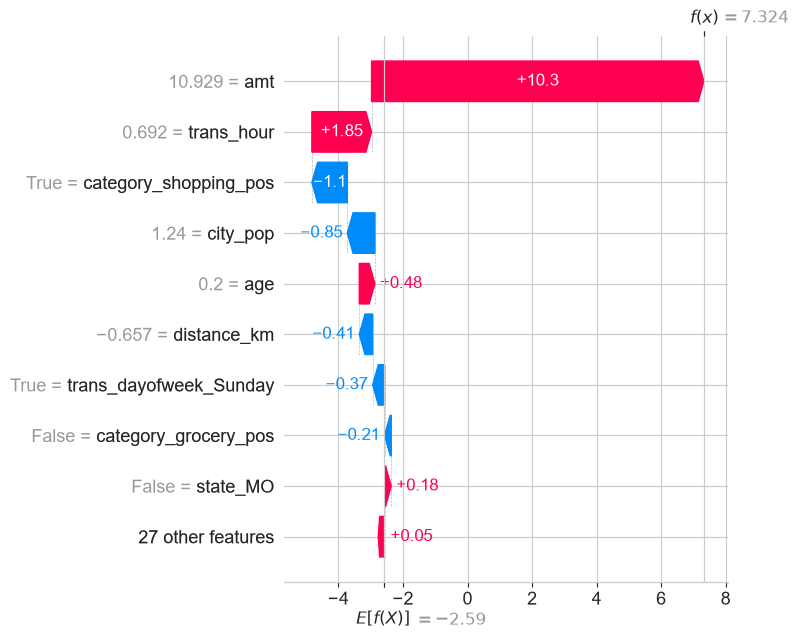

In [52]:
# Waterfall plot for the true positive transaction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[tp_idx],
        base_values=explainer.expected_value,
        data=X_test_reset.iloc[tp_idx],
        feature_names=X_test_reset.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

### 6.4.2 False Positive: Normal Transaction Wrongly Flagged
- This was a normal transaction, but the model predicted as fraud.
- The waterfall plot shows the transaction hour and merchant category (`food_dining`) pushed the prediction towards fraud, even though the transaction was legitimate - a late-night dining purchase that happened to look similar to a fraud pattern.

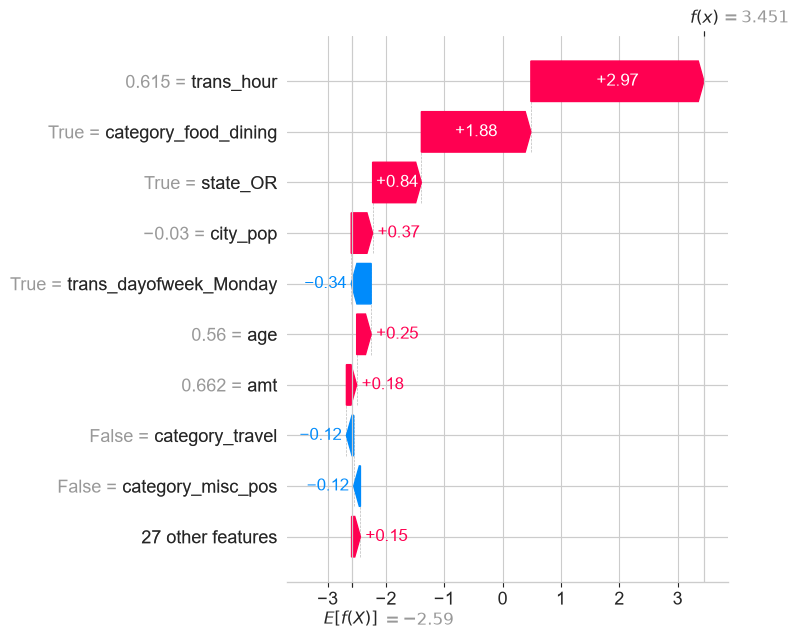

In [53]:
# Waterfall plot for the false positive transaction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fp_idx],
        base_values=explainer.expected_value,
        data=X_test_reset.iloc[fp_idx],
        feature_names=X_test_reset.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

### 6.4.3 False Negative: Fraud the Model Missed
- This was an actual fraud transaction, but the model predicted normal.
- The waterfall plot shows `amt` and transaction hour were both fairly typical for this transaction, so the model didn't get a strong enough signal to flag it - showing a limitation of the current feature set.

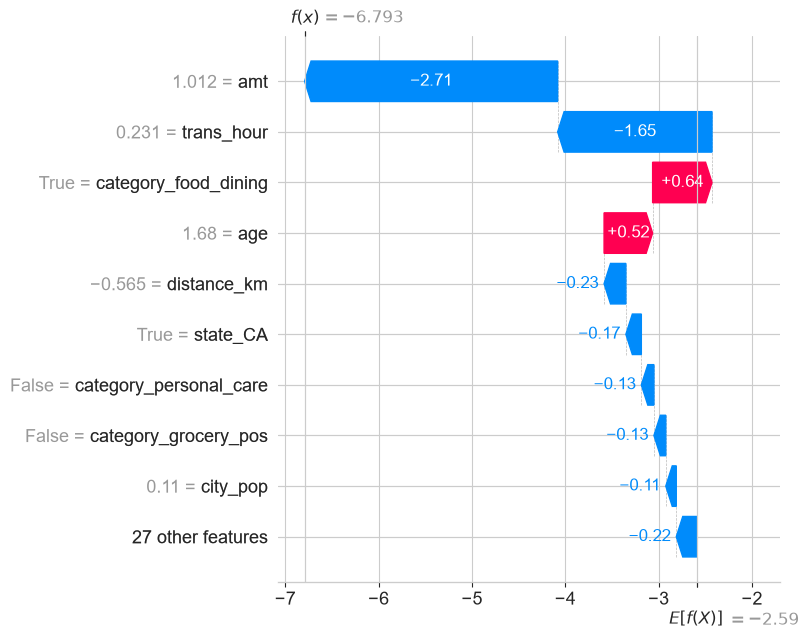

In [54]:
# Waterfall plot for the false negative transaction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fn_idx],
        base_values=explainer.expected_value,
        data=X_test_reset.iloc[fn_idx],
        feature_names=X_test_reset.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

# Key Findings:

- The dataset had 14,444 clean transactions after removing 2 corrupted rows, with fraud making up 12.8% of all transactions - imbalanced, but not extreme.
- Transaction amount was the strongest single signal for fraud throughout the analysis - fraud transactions average about 518 compared to about 67 for normal ones, and this carried through to being the top feature in the SHAP results.
- Fraud showed a strong time-based pattern: late-night hours (10 PM-11 PM) had fraud rates above 40%, while daytime hours stayed under 2%. Weekends (especially Saturday) also saw somewhat higher fraud rates.
- Merchant category mattered too - `shopping_net`, `grocery_pos`, and `misc_net` had fraud rates above 27%, while categories like `home` and `health_fitness` stayed under 5%.
- Customer age showed a small difference between classes (fraud slightly older on average), while city population and customer-merchant distance showed almost no difference between fraud and normal transactions in this dataset.
- For handling class imbalance, the raw data (no resampling) gave the best F1-Score (0.7472), ahead of class weighting, SMOTE, and ADASYN. This suggests the dataset already had enough fraud examples for the model to learn from, and the synthetic resampling methods added noise rather than helping.
- Comparing four models on the raw data: Logistic Regression reached 94.57% accuracy (F1 0.75 for fraud), Decision Tree reached 97.4% (F1 0.90), Random Forest reached 98.1% (F1 0.92), and XGBoost came out on top with 98.23% accuracy and an F1-Score of 0.93 for fraud - so XGBoost was selected as the final model.
- SHAP analysis confirmed that the model's decisions line up with the patterns found during EDA - transaction amount and transaction hour were the two biggest drivers of the fraud predictions, both overall and in the individual case studies (true positive, false positive, and false negative).
- The false positive and false negative examples show where the model can go wrong - sometimes a normal transaction looks unusual and gets flagged, and sometimes a fraud case looks normal and gets missed. This is useful to keep in mind when using the model in practice.
